In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, RSA, load_img_natraster, print_wise, TimeSeries
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [127]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    new_fs: int = 100 # Hz
    channels_idx = np.arange(20)
    max_trials = 7000
    RDM_metric_A: str = 'cosine'
    RDM_metric_B: str = 'correlation'
    k: int = 1
cfg = Cfg()


In [159]:
def characterize_monkey(paths: dict, rasters_dict: dict, monkey_name: str, date: str, new_fs: int, channels_idx: np.ndarray, max_trials: int, RDM_metric_A: str, RDM_metric_B: str, k: int, normalize=False):
    print_wise(f"{monkey_name} on {date}")
    if monkey_name in rasters_dict.keys(): # checks if we already have it
        raster = rasters_dict[monkey_name]
        raster.resample(new_fs)
    else:
        raster = load_img_natraster(paths, monkey_name, date, new_fs=new_fs)
        rasters_dict[monkey_name] = raster
    # end if monkey_name in rasters_dict(): # checks if we already have it

    print_wise(f"raster shape: {raster.get_array().shape}")
    ba_raster = TimeSeries(raster.get_array()[channels_idx, :,:max_trials], new_fs)
    print_wise(f"reduced to: {ba_raster.get_array().shape}")
    fig, axes = plt.subplots(1,2, figsize=(8,8))
    axes[0].imshow(np.mean(raster.get_array(), axis=(2)), aspect=1/5)
    axes[1].plot(np.arange(len(raster))*1000//new_fs, np.mean(raster.get_array(), axis=(0,2)))
    fig.suptitle(f"{monkey_name} - {date}")
    plt.show()
    A2B_list = []
    B2A_list = []
    for idx, resp_t in enumerate(ba_raster):
        if normalize:
            col_norms = np.linalg.norm(resp_t, axis=0)
            # normalize columns
            resp_t = resp_t / col_norms
        _, A2B, B2A =compare_similarity_metrics(resp_t, RDM_metric_A, RDM_metric_B, k)
        A2B_list.append(A2B)
        B2A_list.append(B2A)
        if idx % 5 == 0:
            print_wise(f"computed {idx*1000/new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    # end for idx, resp_t in enumerate(ba_raster):
    plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
    plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
    plt.ylabel("Information Imbalance", fontsize=15)
    plt.xlabel("Time from image onset (ms)", fontsize=15)
    plt.legend()
    return rasters_dict, [A2B, B2A]

In [136]:
rasters_dict = {}

# baby1

13:12:45 - baby1 on 220226to527
13:12:45 - raster shape: (64, 30, 11857)
13:12:45 - reduced to: (20, 30, 7000)


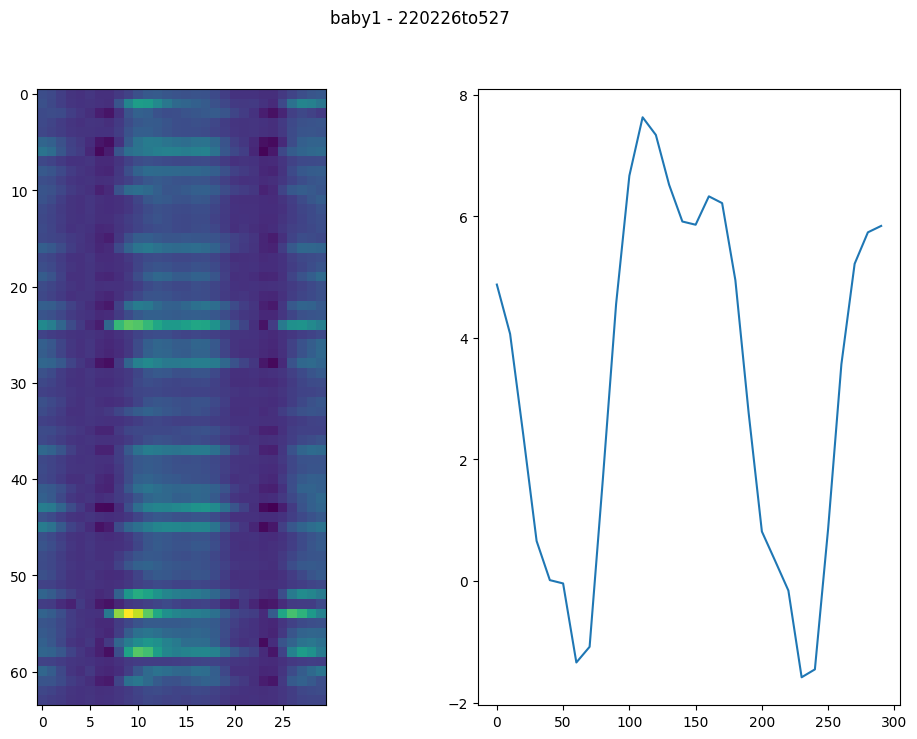

13:12:55 - computed 0ms. 0.001 0.026 
13:13:41 - computed 50ms. 0.001 0.011 
13:14:26 - computed 100ms. 0.001 0.020 
13:15:12 - computed 150ms. 0.001 0.031 
13:15:58 - computed 200ms. 0.001 0.032 
13:16:44 - computed 250ms. 0.001 0.029 


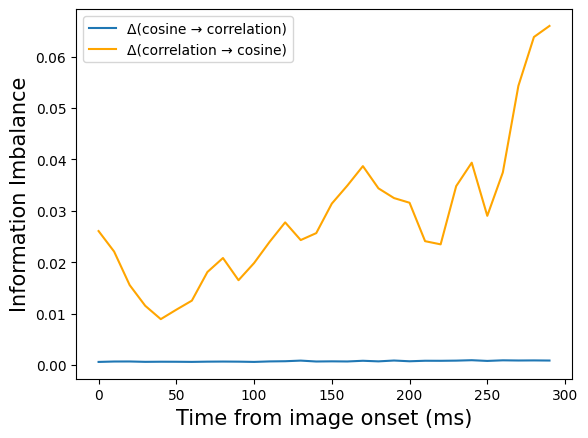

In [147]:
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "baby1", '220226to527', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)

# og

13:17:21 - og on 221104to25
13:17:27 - raster shape: (65, 35, 11857)
13:17:27 - reduced to: (20, 35, 7000)


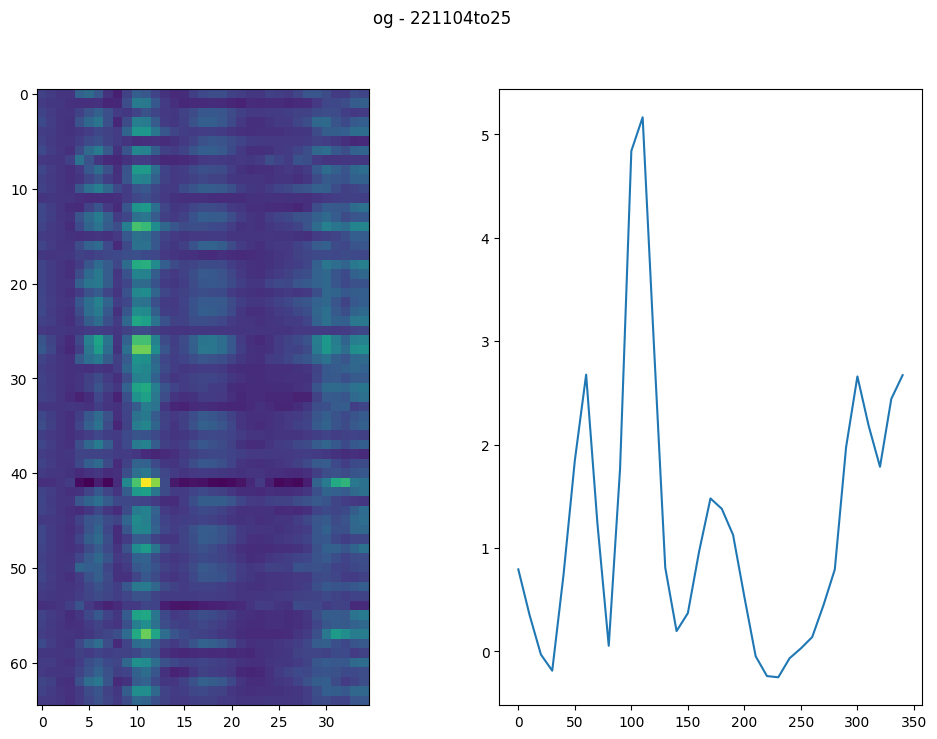

13:17:36 - computed 0ms. 0.001 0.006 
13:18:22 - computed 50ms. 0.000 0.007 
13:19:06 - computed 100ms. 0.000 0.019 
13:19:49 - computed 150ms. 0.001 0.014 
13:20:33 - computed 200ms. 0.001 0.023 
13:21:16 - computed 250ms. 0.001 0.011 
13:22:00 - computed 300ms. 0.000 0.009 


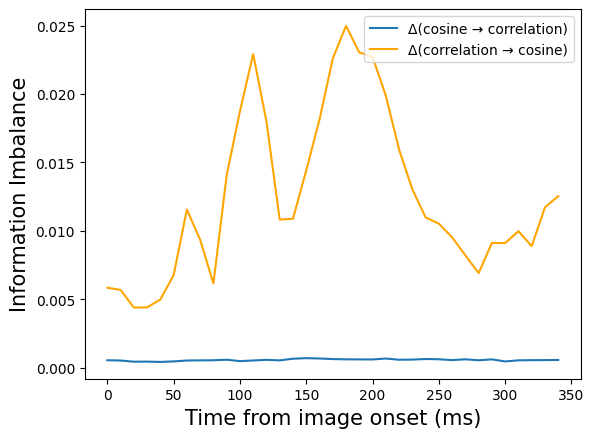

In [148]:
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "og", '221104to25', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)

# octavius

13:22:35 - octavius on 220227to405
13:22:37 - raster shape: (64, 30, 11565)
13:22:37 - reduced to: (20, 30, 7000)


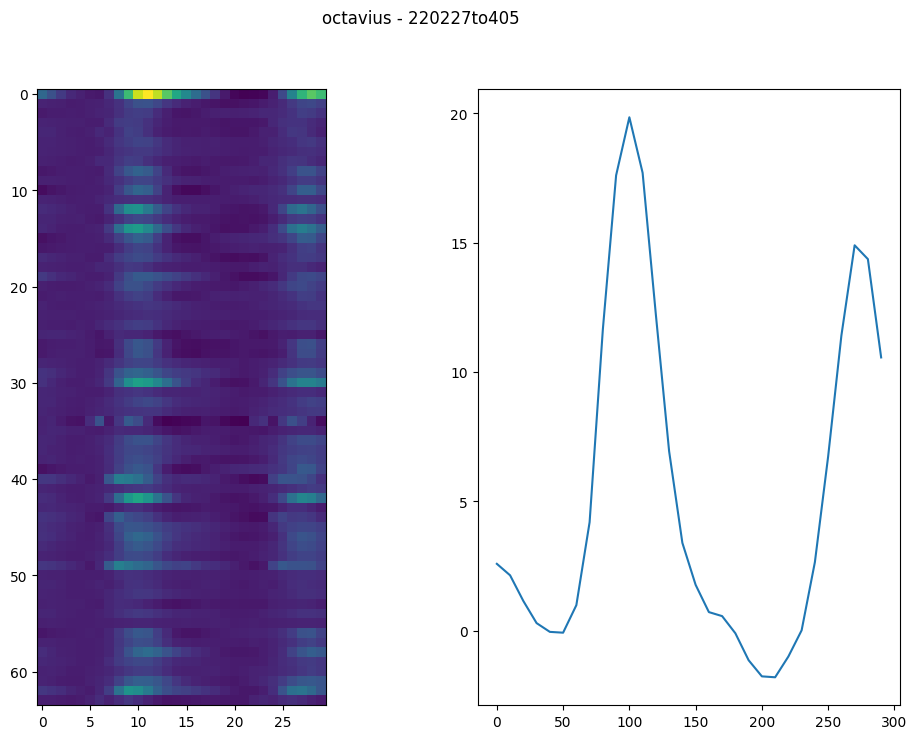

13:22:45 - computed 0ms. 0.001 0.017 
13:23:29 - computed 50ms. 0.001 0.015 
13:24:13 - computed 100ms. 0.001 0.020 
13:24:55 - computed 150ms. 0.001 0.014 
13:25:38 - computed 200ms. 0.001 0.017 
13:26:21 - computed 250ms. 0.001 0.013 


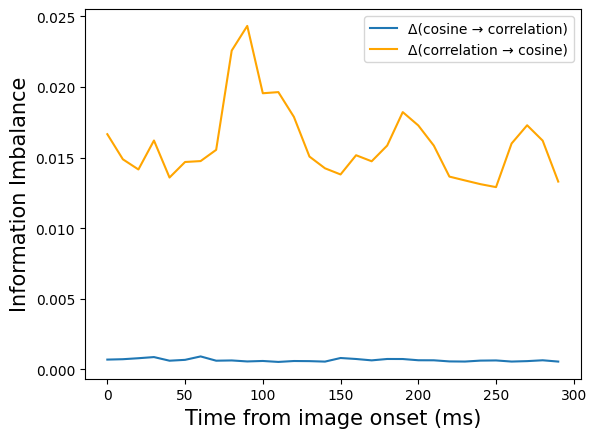

In [149]:
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "octavius", '220227to405', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)

# friday

13:26:56 - friday on 220228to327
13:27:01 - raster shape: (79, 35, 11586)
13:27:01 - reduced to: (20, 35, 7000)


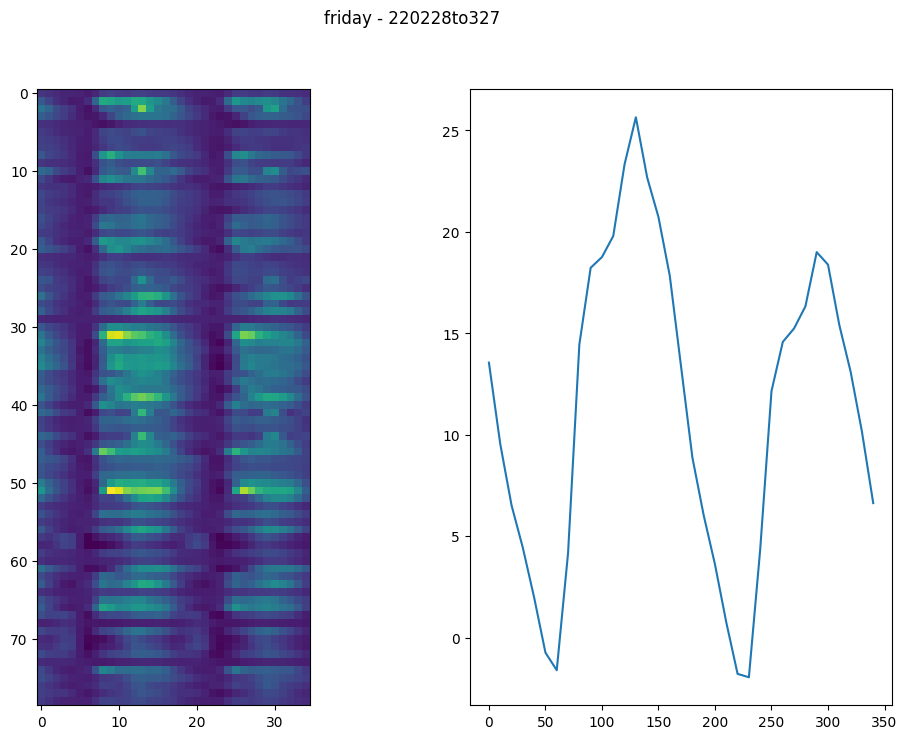

13:27:10 - computed 0ms. 0.001 0.016 
13:27:53 - computed 50ms. 0.000 0.006 
13:28:36 - computed 100ms. 0.000 0.011 
13:29:18 - computed 150ms. 0.001 0.025 
13:30:01 - computed 200ms. 0.001 0.021 
13:30:44 - computed 250ms. 0.000 0.009 
13:31:27 - computed 300ms. 0.001 0.015 


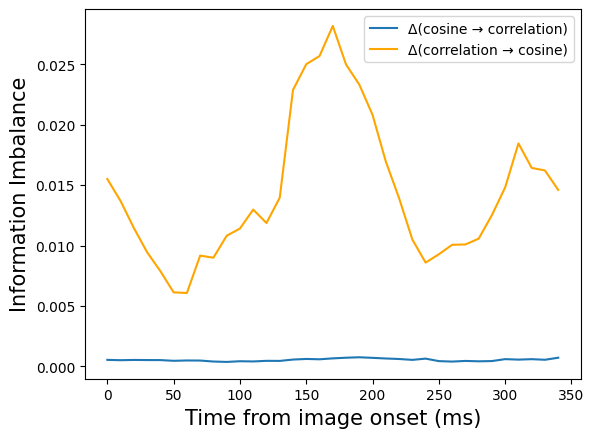

In [150]:
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "friday", '220228to327', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)

# red

13:32:02 - red on 220227
13:32:11 - raster shape: (76, 50, 11855)
13:32:11 - reduced to: (20, 50, 7000)


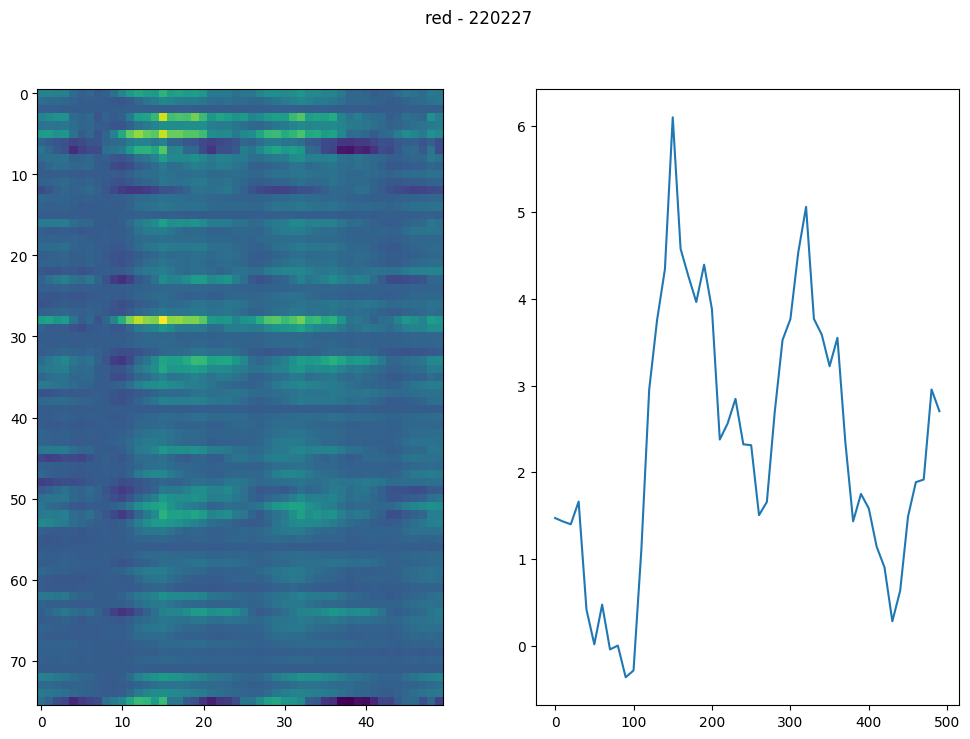

13:32:19 - computed 0ms. 0.000 0.005 
13:33:03 - computed 50ms. 0.000 0.006 
13:33:45 - computed 100ms. 0.000 0.004 
13:34:28 - computed 150ms. 0.000 0.004 
13:35:11 - computed 200ms. 0.000 0.004 
13:35:53 - computed 250ms. 0.000 0.006 
13:36:36 - computed 300ms. 0.000 0.005 
13:37:19 - computed 350ms. 0.000 0.006 
13:38:01 - computed 400ms. 0.000 0.006 
13:38:44 - computed 450ms. 0.000 0.004 


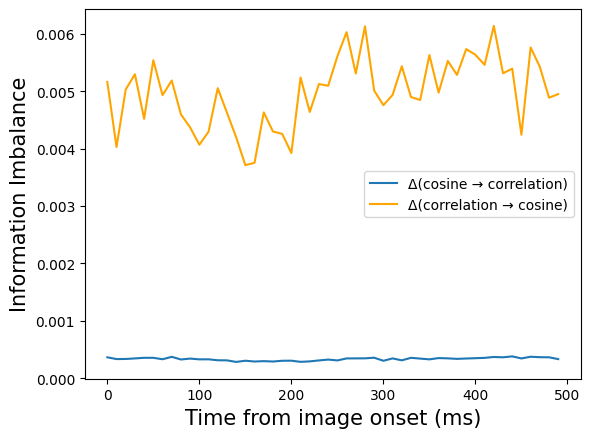

In [151]:
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "red", '220227', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)

# baby5

13:39:19 - baby5 on 221104to24
13:39:35 - raster shape: (383, 52, 3210)
13:39:35 - reduced to: (20, 52, 3210)


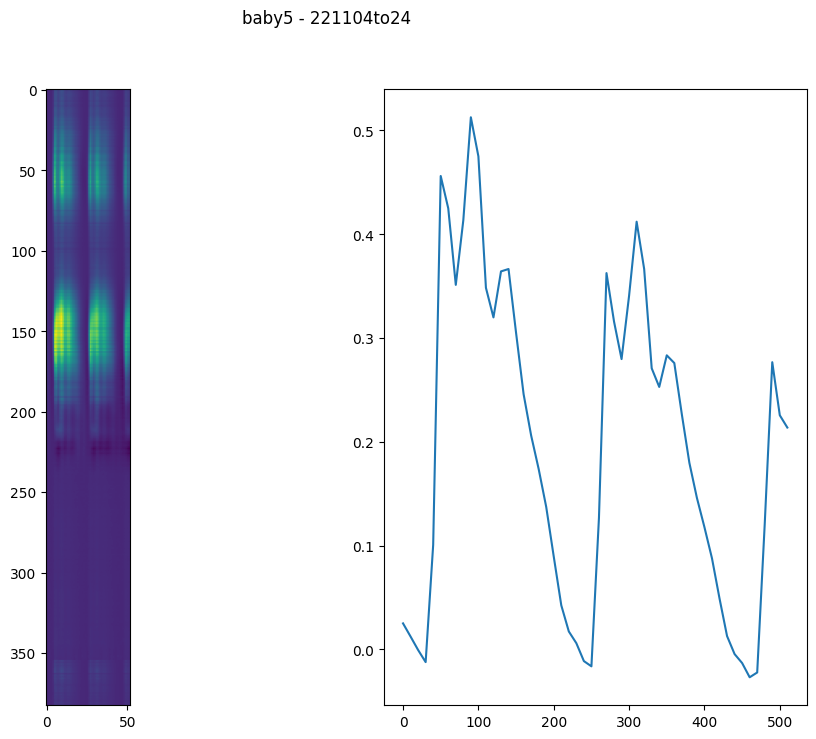

13:39:37 - computed 0ms. 0.003 0.020 
13:39:45 - computed 50ms. 0.002 0.026 
13:39:54 - computed 100ms. 0.002 0.047 
13:40:02 - computed 150ms. 0.002 0.079 
13:40:11 - computed 200ms. 0.003 0.252 
13:40:19 - computed 250ms. 0.004 0.179 
13:40:27 - computed 300ms. 0.002 0.028 
13:40:36 - computed 350ms. 0.001 0.030 
13:40:44 - computed 400ms. 0.002 0.040 
13:40:53 - computed 450ms. 0.002 0.019 
13:41:01 - computed 500ms. 0.002 0.030 


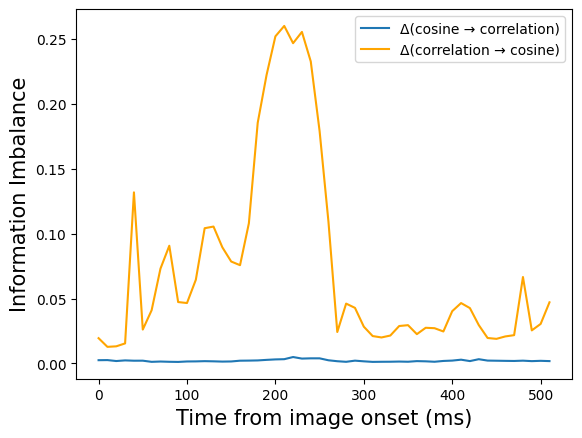

In [152]:
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "baby5", '221104to24', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)

# three0

In [170]:
f = lambda u, v: rbf_distance(u, v, sigma=20)

16:30:51 - three0 on 250313
16:30:51 - raster shape: (383, 30, 776)
16:30:51 - reduced to: (20, 30, 776)


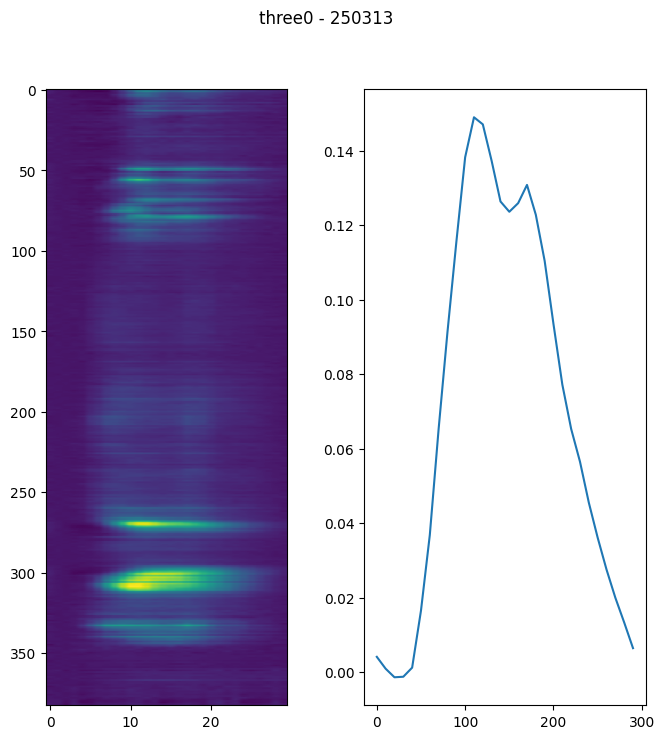

16:30:51 - computed 0ms. 0.020 0.006 
16:30:54 - computed 50ms. 0.028 0.004 
16:30:57 - computed 100ms. 0.056 0.008 
16:30:59 - computed 150ms. 0.061 0.007 
16:31:02 - computed 200ms. 0.058 0.007 
16:31:04 - computed 250ms. 0.027 0.006 


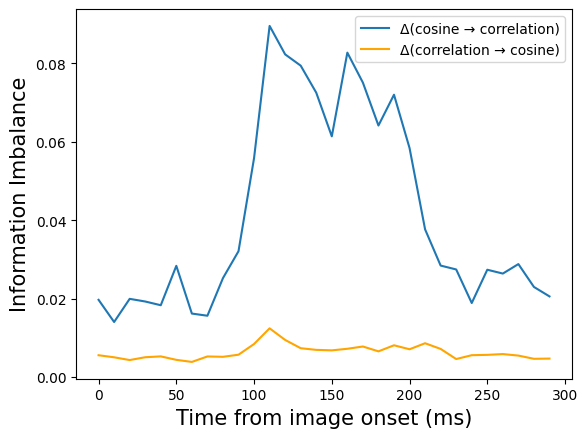

In [171]:
from sklearn.metrics.pairwise import rbf_kernel
def rbf_distance(u, v, sigma=1.0):
    diff = u - v
    sqdist = np.dot(diff, diff)
    return 1.0 - np.exp(-sqdist / (2 * sigma**2))
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "three0", '250313', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, f, cfg.k)# l, cfg.k, normalize=True)

14:55:50 - baby1 on 220226to527
14:55:50 - raster shape: (64, 30, 11857)
14:55:50 - reduced to: (20, 30, 7000)


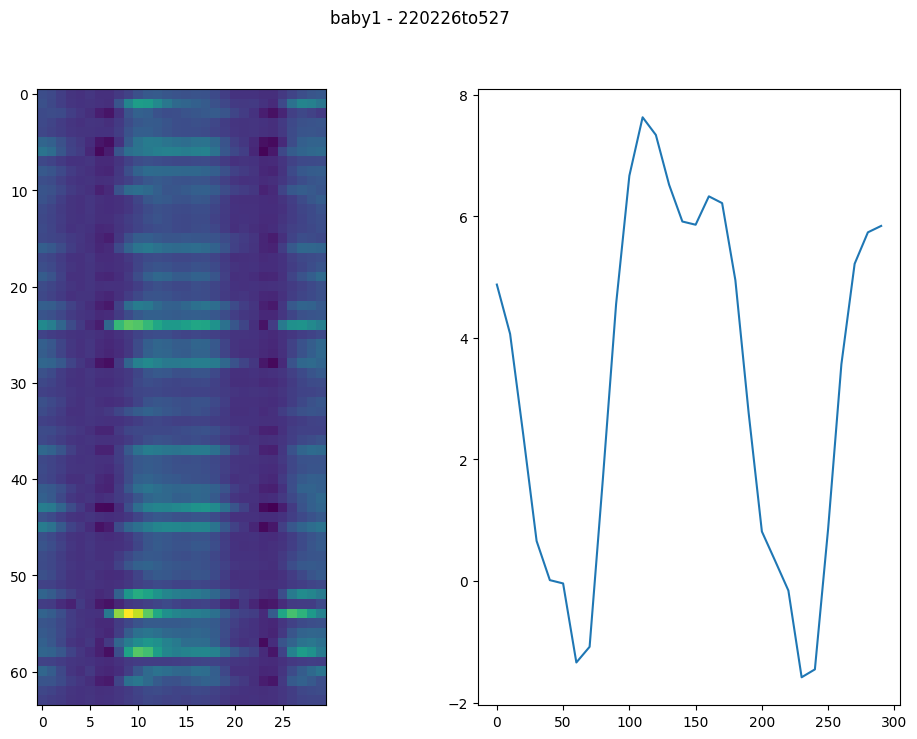

14:55:59 - computed 0ms. 0.001 0.026 
14:56:42 - computed 50ms. 0.001 0.011 
14:57:26 - computed 100ms. 0.001 0.020 
14:58:09 - computed 150ms. 0.001 0.031 
14:58:55 - computed 200ms. 0.001 0.032 
14:59:38 - computed 250ms. 0.001 0.029 


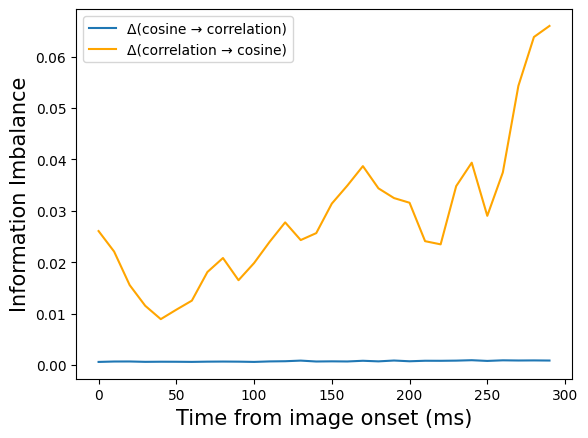

In [153]:
rasters_dict, _ = characterize_monkey(paths, rasters_dict, "baby1", '220226to527', cfg.new_fs, cfg.channels_idx, cfg.max_trials, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)

In [ ]:
raster_red = load_img_natraster(paths, 'red', '220227', new_fs=cfg.new_fs)
print(raster_red.get_array().shape)
ba_raster_red = TimeSeries(raster_red.get_array()[:30, :,:3000], cfg.new_fs)

(76, 50, 11855)


Text(0.5, 0.98, 'a')

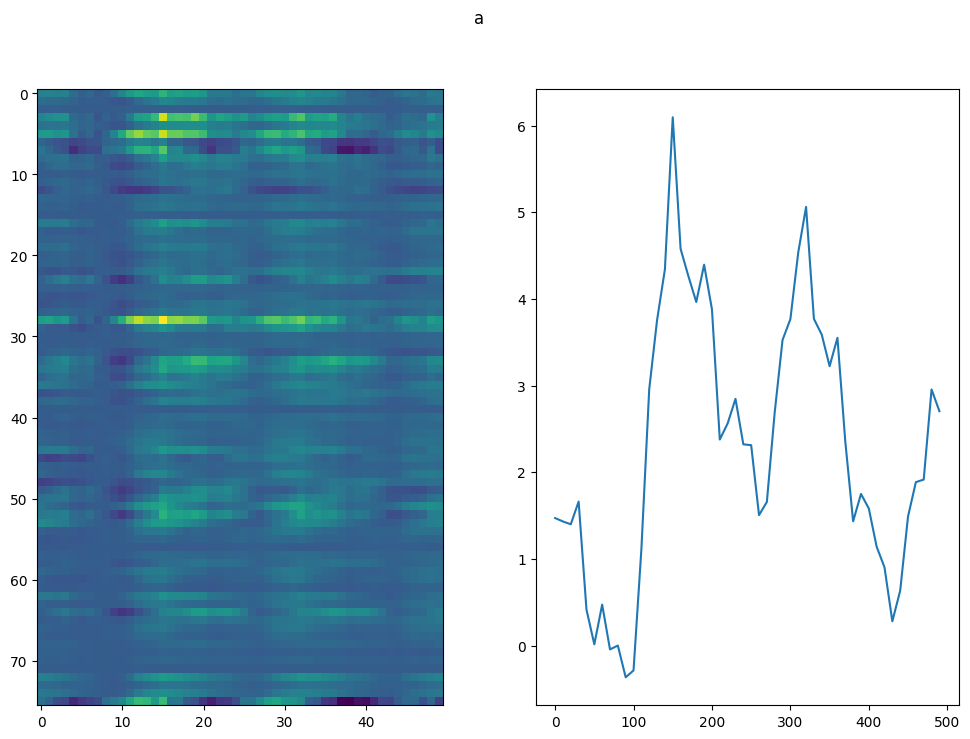

In [121]:
fig, axes = plt.subplots(1,2, figsize=(12,8))
axes[0].imshow(np.mean(raster_red.get_array(), axis=(2)))
axes[1].plot(np.arange(len(raster_red))*1000//cfg.new_fs, np.mean(raster_red.get_array(), axis=(0,2)))
fig.suptitle("a")

In [53]:
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_red):
    # col_norms = np.linalg.norm(resp_t, axis=0)
    # # normalize columns
    # resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")

19:28:59 - computed 0ms. 0.001 0.009 
19:29:01 - computed 10ms. 0.001 0.008 
19:29:03 - computed 20ms. 0.001 0.007 
19:29:04 - computed 30ms. 0.001 0.007 
19:29:06 - computed 40ms. 0.001 0.008 
19:29:07 - computed 50ms. 0.001 0.007 
19:29:09 - computed 60ms. 0.001 0.008 
19:29:10 - computed 70ms. 0.001 0.008 
19:29:12 - computed 80ms. 0.001 0.007 
19:29:13 - computed 90ms. 0.001 0.007 
19:29:15 - computed 100ms. 0.001 0.006 
19:29:16 - computed 110ms. 0.001 0.007 
19:29:18 - computed 120ms. 0.001 0.005 
19:29:19 - computed 130ms. 0.001 0.006 
19:29:21 - computed 140ms. 0.001 0.006 
19:29:22 - computed 150ms. 0.001 0.005 
19:29:24 - computed 160ms. 0.001 0.006 
19:29:26 - computed 170ms. 0.001 0.005 
19:29:27 - computed 180ms. 0.001 0.007 
19:29:29 - computed 190ms. 0.001 0.005 
19:29:30 - computed 200ms. 0.001 0.006 
19:29:32 - computed 210ms. 0.001 0.006 
19:29:33 - computed 220ms. 0.001 0.007 
19:29:35 - computed 230ms. 0.001 0.007 
19:29:36 - computed 240ms. 0.001 0.007 
19:29:38 - 

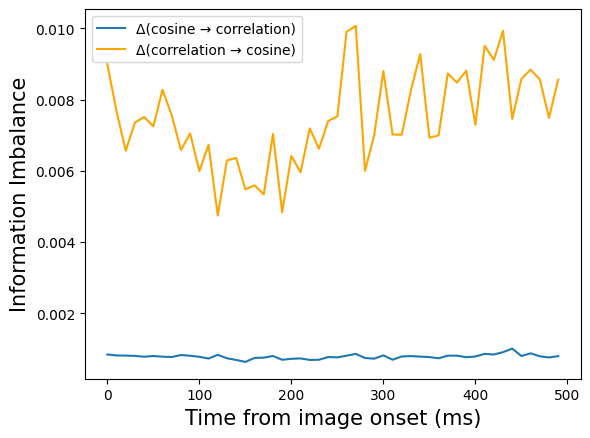

In [54]:
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

In [ ]:
raster_baby5 = load_img_natraster(paths, 'baby5', '221104to24', new_fs=cfg.new_fs)
raster_baby5.get_array().shape

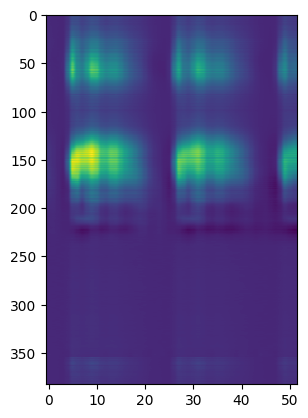

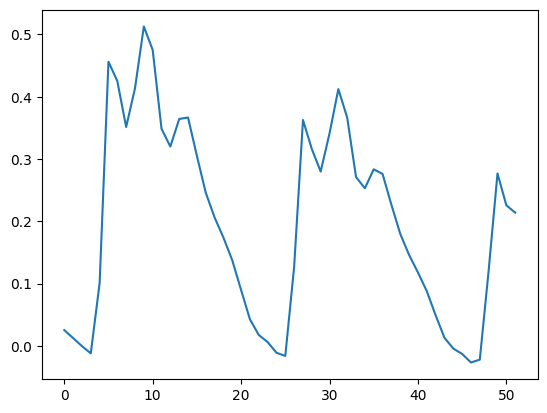

In [35]:
plt.imshow(np.mean(raster_baby5.get_array(), axis=2), aspect=1/5)
plt.figure()
plt.plot(np.mean(raster_baby5.get_array(), axis=(0,2)))

10:14:35 - computed 0ms. 1.005 1.070 
10:14:36 - computed 10ms. 0.966 1.156 
10:14:37 - computed 20ms. 1.010 1.010 
10:14:39 - computed 30ms. 0.996 1.053 
10:14:40 - computed 40ms. 0.707 0.977 
10:14:42 - computed 50ms. 0.007 0.011 
10:14:44 - computed 60ms. 0.007 0.007 
10:14:47 - computed 70ms. 0.090 0.118 
10:14:49 - computed 80ms. 0.080 0.090 
10:14:51 - computed 90ms. 0.014 0.018 
10:14:53 - computed 100ms. 0.007 0.009 
10:14:56 - computed 110ms. 0.061 0.090 
10:14:58 - computed 120ms. 0.168 0.204 
10:15:00 - computed 130ms. 0.120 0.167 
10:15:03 - computed 140ms. 0.089 0.102 
10:15:05 - computed 150ms. 0.116 0.164 
10:15:07 - computed 160ms. 0.241 0.393 
10:15:09 - computed 170ms. 0.422 0.562 
10:15:10 - computed 180ms. 0.525 0.598 
10:15:12 - computed 190ms. 0.637 0.580 
10:15:13 - computed 200ms. 0.792 0.763 
10:15:14 - computed 210ms. 0.941 0.973 
10:15:15 - computed 220ms. 0.980 0.906 
10:15:16 - computed 230ms. 0.989 0.982 
10:15:17 - computed 240ms. 1.010 0.961 
10:15:19 - 

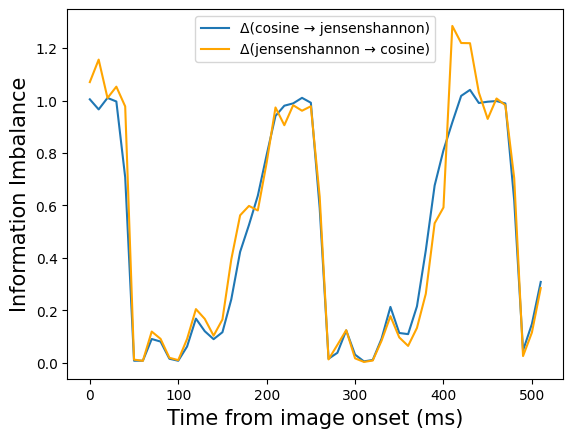

In [83]:
ba_raster_baby5 = TimeSeries(raster_baby5.get_array()[:20, :, :], cfg.new_fs)
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_baby5):
    col_norms = np.linalg.norm(resp_t, axis=0)
    # normalize columns
    resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

In [30]:
import h5py
from general_utils.utils import TimeSeries, BrainAreas
def load_img_natraster_three0(paths: dict[str: str], monkey_name, date, ev_od, new_fs=None, brain_area=None):
    rasters_path = f"{paths['livingstone_lab']}/tiziano/data/{monkey_name}_natraster{ev_od}{date}.mat"
    with h5py.File(rasters_path, "r") as f:
        rasters = f[f"natraster{ev_od}"][:]  
        
    rasters = rasters.astype(np.float32)
    rasters = rasters.transpose(2, 1, 0)
    rasters = TimeSeries(rasters, 1000)
    if brain_area is not None:
            brain_areas_obj = BrainAreas(monkey_name)
            rasters = brain_areas_obj.slice_brain_area(rasters, brain_area)
    # end if brain_area is not None:
    if new_fs is not None:
        rasters.resample(new_fs)
    # if new_fs is not None:
    return rasters
# EOF


In [58]:
# merge Even and odd trials (based also on the images) 
raster_three0 = load_img_natraster_three0(paths, 'three0', '250313', 'Od', new_fs=cfg.new_fs)
print(raster_three0.get_array().shape)
ba_raster_three0 = TimeSeries(raster_three0.get_array()[:30,:,:], cfg.new_fs)

(383, 30, 776)


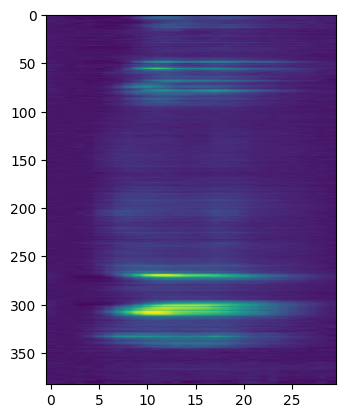

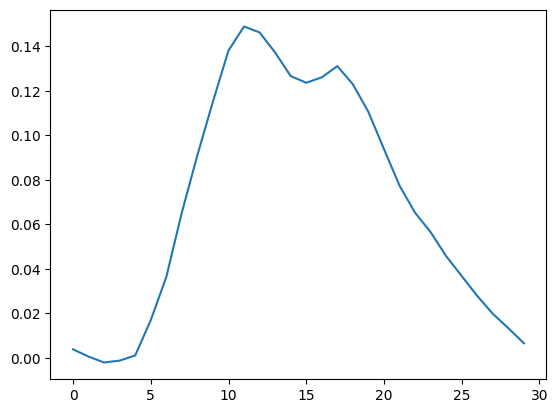

In [57]:
plt.imshow(np.mean(raster_three0.get_array(), axis=2),aspect=1/10) 
plt.figure()
plt.plot(np.mean(raster_three0.get_array(), axis=(0,2)))

20:01:21 - computed 0ms. 0.198 0.108 
20:01:21 - computed 10ms. 0.186 0.098 
20:01:22 - computed 20ms. 0.179 0.112 
20:01:22 - computed 30ms. 0.183 0.113 
20:01:22 - computed 40ms. 0.183 0.107 
20:01:22 - computed 50ms. 0.196 0.098 
20:01:22 - computed 60ms. 0.186 0.103 
20:01:22 - computed 70ms. 0.189 0.116 
20:01:22 - computed 80ms. 0.189 0.110 
20:01:22 - computed 90ms. 0.196 0.110 
20:01:22 - computed 100ms. 0.251 0.119 
20:01:22 - computed 110ms. 0.261 0.130 
20:01:22 - computed 120ms. 0.251 0.126 
20:01:22 - computed 130ms. 0.231 0.119 
20:01:22 - computed 140ms. 0.221 0.116 
20:01:22 - computed 150ms. 0.221 0.118 
20:01:23 - computed 160ms. 0.234 0.113 
20:01:23 - computed 170ms. 0.239 0.121 
20:01:23 - computed 180ms. 0.215 0.123 
20:01:23 - computed 190ms. 0.210 0.115 
20:01:23 - computed 200ms. 0.199 0.110 
20:01:23 - computed 210ms. 0.207 0.123 
20:01:23 - computed 220ms. 0.191 0.109 
20:01:23 - computed 230ms. 0.184 0.111 
20:01:23 - computed 240ms. 0.175 0.102 
20:01:23 - 

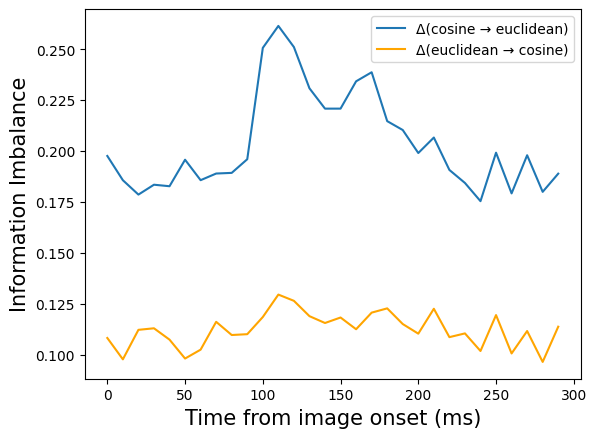

In [72]:
A2B_list=[]
B2A_list=[]
for idx, resp_t in enumerate(ba_raster_three0):
    # col_norms = np.linalg.norm(resp_t, axis=0)
    # # normalize columns
    # resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

# Baby 1

In [85]:
raster_baby1 = load_img_natraster(paths, 'baby1', '220226to527', new_fs=cfg.new_fs)
raster_baby1.get_array().shape

(64, 30, 11857)

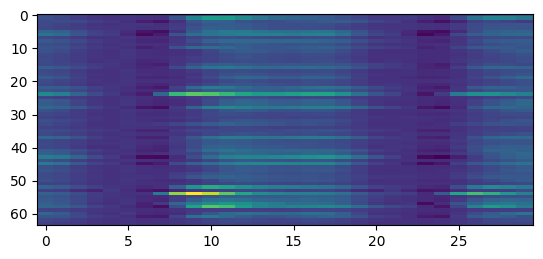

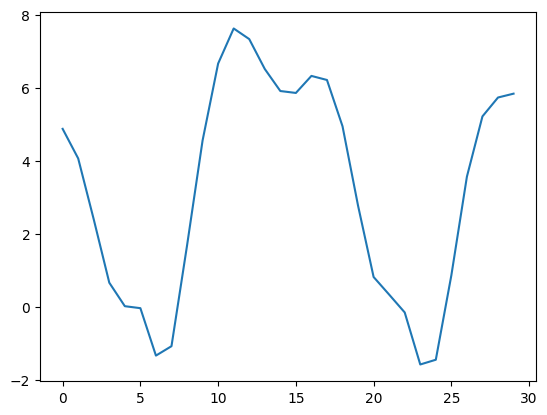

In [87]:
plt.imshow(np.mean(raster_baby1.get_array(), axis=2), aspect=1/5)
plt.figure()
plt.plot(np.mean(raster_baby1.get_array(), axis=(0,2)))

11:59:46 - computed 0ms. 0.001 0.027 
12:00:15 - computed 100ms. 0.001 0.021 
12:00:44 - computed 200ms. 0.001 0.018 


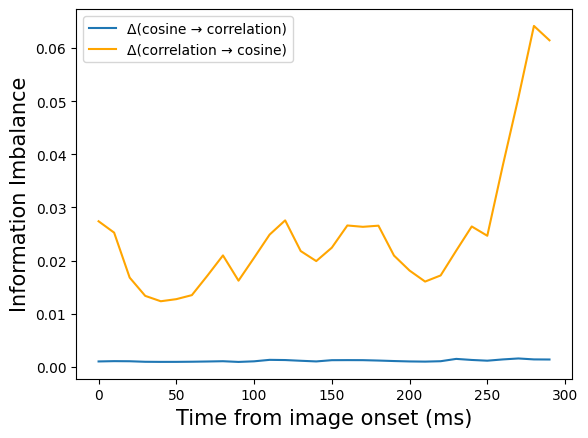

In [ ]:
ba_raster_baby1 = TimeSeries(raster_baby1.get_array()[:20, :, :4000], cfg.new_fs)
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_baby1):
    col_norms = np.linalg.norm(resp_t, axis=0)
    # normalize columns
    resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

# Baby 1

In [96]:
raster_octavius = load_img_natraster(paths, 'octavius', '220227to405', new_fs=cfg.new_fs)
raster_octavius.get_array().shape

(64, 30, 11565)

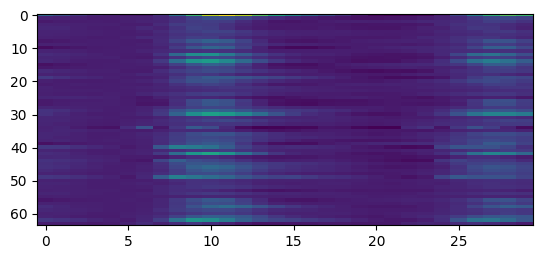

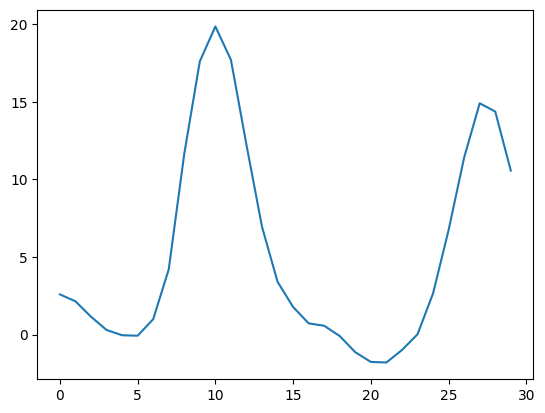

In [97]:
plt.imshow(np.mean(raster_octavius.get_array(), axis=2), aspect=1/5)
plt.figure()
plt.plot(np.mean(raster_octavius.get_array(), axis=(0,2)))

12:05:44 - computed 0ms. 0.001 0.018 
12:05:47 - computed 10ms. 0.001 0.015 
12:05:50 - computed 20ms. 0.001 0.018 
12:05:52 - computed 30ms. 0.001 0.017 
12:05:55 - computed 40ms. 0.001 0.014 
12:05:58 - computed 50ms. 0.001 0.016 
12:06:01 - computed 60ms. 0.001 0.015 
12:06:04 - computed 70ms. 0.001 0.018 
12:06:06 - computed 80ms. 0.001 0.021 
12:06:09 - computed 90ms. 0.001 0.024 
12:06:12 - computed 100ms. 0.001 0.019 
12:06:15 - computed 110ms. 0.001 0.018 
12:06:17 - computed 120ms. 0.001 0.018 
12:06:20 - computed 130ms. 0.001 0.018 
12:06:23 - computed 140ms. 0.001 0.016 
12:06:26 - computed 150ms. 0.001 0.016 
12:06:29 - computed 160ms. 0.001 0.017 
12:06:31 - computed 170ms. 0.001 0.017 
12:06:34 - computed 180ms. 0.001 0.020 
12:06:37 - computed 190ms. 0.001 0.022 
12:06:40 - computed 200ms. 0.001 0.018 
12:06:42 - computed 210ms. 0.001 0.017 
12:06:45 - computed 220ms. 0.001 0.018 
12:06:48 - computed 230ms. 0.001 0.011 
12:06:51 - computed 240ms. 0.001 0.014 
12:06:53 - 

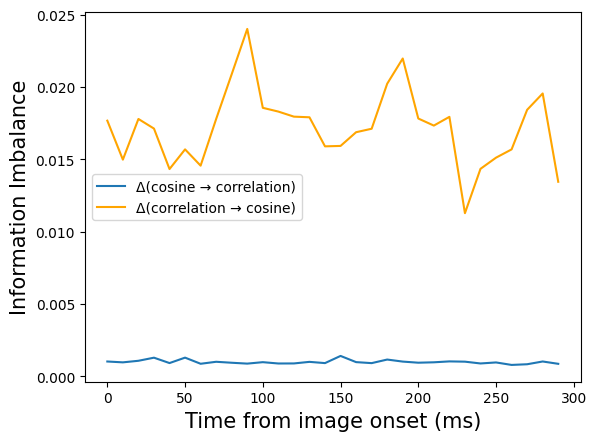

In [98]:
ba_raster_octavius = TimeSeries(raster_octavius.get_array()[:20, :, :4000], cfg.new_fs)
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_octavius):
    col_norms = np.linalg.norm(resp_t, axis=0)
    # normalize columns
    resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

# Friday

In [91]:
raster_friday = load_img_natraster(paths, 'friday', '220228to327', new_fs=cfg.new_fs)
raster_friday.get_array().shape

(79, 35, 11586)

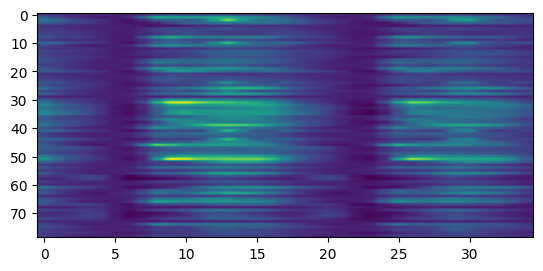

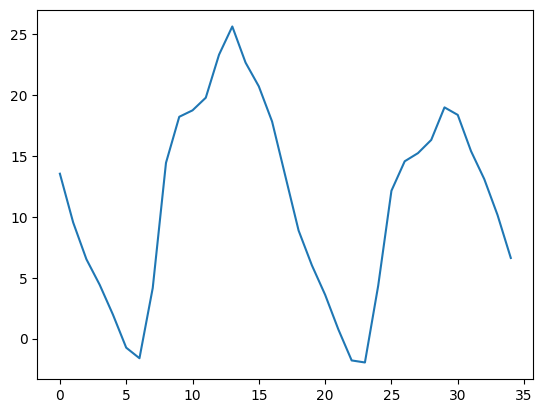

In [94]:
plt.imshow(np.mean(raster_friday.get_array(), axis=2), aspect=1/5)
plt.figure()
plt.plot(np.mean(raster_friday.get_array(), axis=(0,2)))

12:02:44 - computed 0ms. 0.001 0.018 
12:02:47 - computed 10ms. 0.001 0.016 
12:02:50 - computed 20ms. 0.001 0.014 
12:02:52 - computed 30ms. 0.001 0.012 
12:02:55 - computed 40ms. 0.001 0.011 
12:02:58 - computed 50ms. 0.001 0.008 
12:03:00 - computed 60ms. 0.001 0.008 
12:03:03 - computed 70ms. 0.001 0.009 
12:03:06 - computed 80ms. 0.001 0.011 
12:03:09 - computed 90ms. 0.001 0.010 
12:03:12 - computed 100ms. 0.001 0.012 
12:03:14 - computed 110ms. 0.001 0.016 
12:03:17 - computed 120ms. 0.001 0.016 
12:03:20 - computed 130ms. 0.001 0.017 
12:03:23 - computed 140ms. 0.001 0.026 
12:03:25 - computed 150ms. 0.001 0.028 
12:03:28 - computed 160ms. 0.001 0.030 
12:03:31 - computed 170ms. 0.001 0.031 
12:03:34 - computed 180ms. 0.001 0.029 
12:03:37 - computed 190ms. 0.001 0.027 
12:03:39 - computed 200ms. 0.001 0.021 
12:03:42 - computed 210ms. 0.001 0.020 
12:03:45 - computed 220ms. 0.001 0.016 
12:03:48 - computed 230ms. 0.001 0.012 
12:03:52 - computed 240ms. 0.001 0.010 
12:03:54 - 

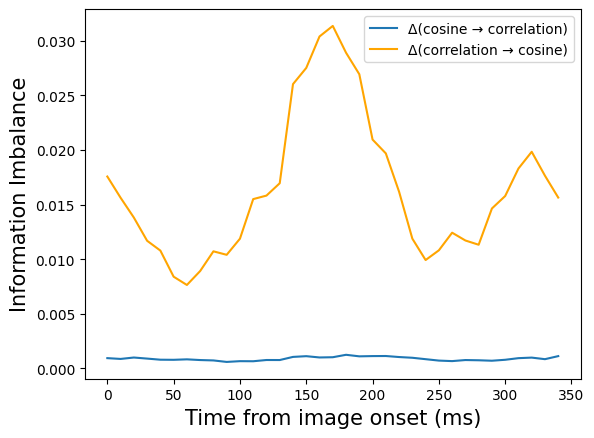

In [95]:
ba_raster_friday = TimeSeries(raster_friday.get_array()[:20, :, :4000], cfg.new_fs)
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_friday):
    col_norms = np.linalg.norm(resp_t, axis=0)
    # normalize columns
    resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

# OG

In [99]:
raster_og = load_img_natraster(paths, 'og', '221104to25', new_fs=cfg.new_fs)
raster_og.get_array().shape

(65, 35, 11857)

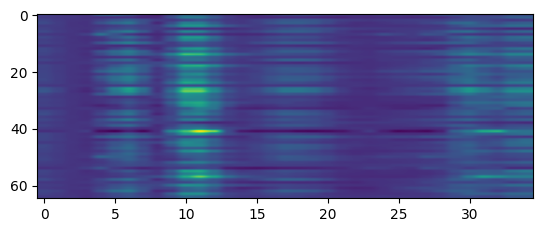

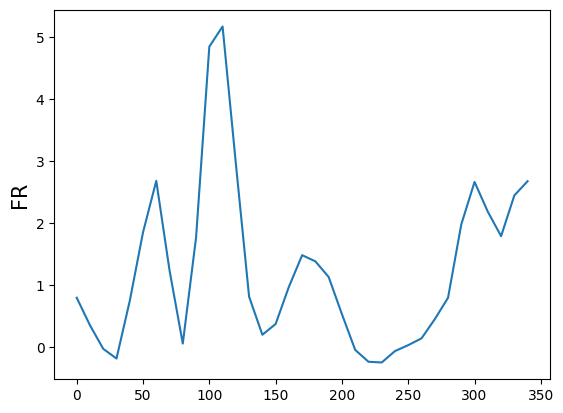

In [ ]:
plt.imshow(np.mean(raster_og.get_array(), axis=2), aspect=1/5)
plt.figure()
plt.plot(np.arange(len(raster_og))*1000//cfg.new_fs, np.mean(raster_og.get_array(), axis=(0,2)))
plt.ylabel("FR", fontsize=15);


12:09:41 - computed 0ms. 0.001 0.007 
12:09:44 - computed 10ms. 0.001 0.006 
12:09:46 - computed 20ms. 0.001 0.005 
12:09:49 - computed 30ms. 0.001 0.005 
12:09:52 - computed 40ms. 0.001 0.006 
12:09:55 - computed 50ms. 0.001 0.009 
12:09:57 - computed 60ms. 0.001 0.012 
12:10:00 - computed 70ms. 0.001 0.008 
12:10:03 - computed 80ms. 0.001 0.004 
12:10:06 - computed 90ms. 0.001 0.011 
12:10:08 - computed 100ms. 0.001 0.020 
12:10:11 - computed 110ms. 0.001 0.022 
12:10:14 - computed 120ms. 0.001 0.017 
12:10:17 - computed 130ms. 0.001 0.009 
12:10:20 - computed 140ms. 0.001 0.008 
12:10:22 - computed 150ms. 0.001 0.007 
12:10:25 - computed 160ms. 0.001 0.007 
12:10:28 - computed 170ms. 0.001 0.011 
12:10:31 - computed 180ms. 0.001 0.009 
12:10:33 - computed 190ms. 0.001 0.008 
12:10:36 - computed 200ms. 0.001 0.008 
12:10:39 - computed 210ms. 0.001 0.007 
12:10:42 - computed 220ms. 0.001 0.006 
12:10:45 - computed 230ms. 0.001 0.005 
12:10:47 - computed 240ms. 0.001 0.007 
12:10:50 - 

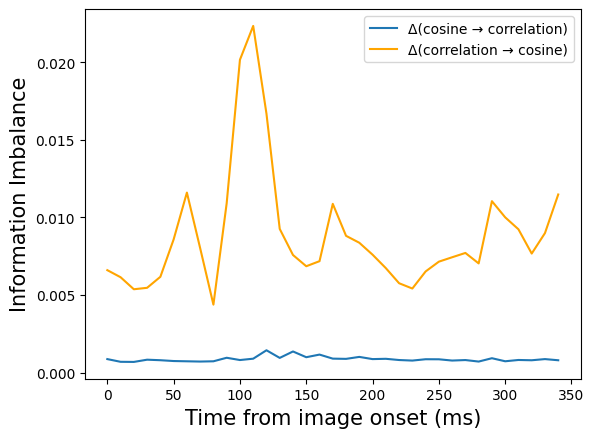

In [101]:
ba_raster_og = TimeSeries(raster_og.get_array()[:20, :, :4000], cfg.new_fs)
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_og):
    col_norms = np.linalg.norm(resp_t, axis=0)
    # normalize columns
    resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()